In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# EDA Assignment â€“ Loan Approval Analysis
# Problem Statement

# You have been provided with a Loan Approval Dataset containing customer information, loan details, and loan approval status. Your task is to perform Data Loading, Data Cleaning, Exploratory Data Analysis (EDA), and Data Visualization using Pandas, NumPy, Matplotlib, and Seaborn.

# Task 1: Data Loading
# Load the Loan dataset.
# Display the first and last five records.
# Check the dataset shape.
# Display column names and data types.

loan_df = pd.read_csv('loans.csv')
print(loan_df.head())
print()
print(loan_df.tail())


  Loan_ID Applicant_ID  Loan_Amount  Loan_Term_Months  Interest_Rate  \
0    L001         A001      1060734               240           9.31   
1    L002         A002      2415051               120          12.39   
2    L003         A003      2374314               120          12.04   
3    L004         A004      2433854               240          11.40   
4    L005         A005      1018501                60          11.59   

  Loan_Purpose Loan_Status  
0     Personal    Approved  
1         Home    Rejected  
2    Education    Approved  
3    Education    Approved  
4          Car    Approved  

   Loan_ID Applicant_ID  Loan_Amount  Loan_Term_Months  Interest_Rate  \
25    L026         A026       438331                60           8.46   
26    L027         A027      2329506               180          10.31   
27    L028         A028      1565722               240          12.37   
28    L029         A029      1362600               180          10.04   
29    L030         A030    

In [8]:
print(loan_df.shape)
print()
print(loan_df.columns)
print()
print(loan_df.dtypes)

(30, 7)

Index(['Loan_ID', 'Applicant_ID', 'Loan_Amount', 'Loan_Term_Months',
       'Interest_Rate', 'Loan_Purpose', 'Loan_Status'],
      dtype='object')

Loan_ID              object
Applicant_ID         object
Loan_Amount           int64
Loan_Term_Months      int64
Interest_Rate       float64
Loan_Purpose         object
Loan_Status          object
dtype: object


In [9]:
# Task 2: Data Cleaning
# Check for missing values and handle them.

loan_df.isnull().sum()

Loan_ID             0
Applicant_ID        0
Loan_Amount         0
Loan_Term_Months    0
Interest_Rate       0
Loan_Purpose        0
Loan_Status         0
dtype: int64

In [10]:
# Remove duplicate records.

loan_df.duplicated().sum()

np.int64(0)

In [11]:
# Convert categorical values into a consistent format.
# Verify and correct data types if required.
loan_df.dtypes

Loan_ID              object
Applicant_ID         object
Loan_Amount           int64
Loan_Term_Months      int64
Interest_Rate       float64
Loan_Purpose         object
Loan_Status          object
dtype: object

In [12]:
application_df = pd.read_csv('applications.csv')
branch_df = pd.read_csv('branches.csv')
df1 = pd.merge(loan_df,application_df, how='inner', on='Applicant_ID')
df2 = pd.merge(df1,branch_df, how='inner', on='Region')
df2.head()

,Loan_ID,Applicant_ID,Loan_Amount,Loan_Term_Months,Interest_Rate,Loan_Purpose,Loan_Status,Applicant_Name,Gender,Age,Education,Occupation,Applicant_Income,Credit_Score,Region,Branch_ID,Branch_Manager,Total_Employees
0,L001,A001,1060734,240,9.31,Personal,Approved,Applicant_1,Female,31,Post Graduate,Self Employed,31328,587,Pune,B101,Rahul,18
1,L002,A002,2415051,120,12.39,Home,Rejected,Applicant_2,Female,25,Diploma,Salaried,29914,594,Nashik,B104,Priya,14
2,L003,A003,2374314,120,12.04,Education,Approved,Applicant_3,Female,26,Graduate,Salaried,97226,767,Pune,B101,Rahul,18
3,L004,A004,2433854,240,11.40,Education,Approved,Applicant_4,Male,36,Diploma,Self Employed,101414,581,Nashik,B104,Priya,14
4,L005,A005,1018501,60,11.59,Car,Approved,Applicant_5,Male,36,Graduate,Self Employed,42455,698,Nashik,B104,Priya,14


In [13]:
# Task 3: Data Analysis

# Perform the following analysis:

# Find the total number of loan applications.
print("Total number of loan application : ",df2['Loan_ID'].count())

# Find the total number of approved and rejected loans.
print("\n",df2.groupby(by='Loan_Status')['Loan_Status'].value_counts())

# Calculate the average applicant income.
print('\nAverage applicatant income : ', df2['Applicant_Income'].mean())

# Calculate the average loan amount.
print("\nAverage loan amount : ",df2['Loan_Amount'].mean())

# Find the average loan amount by education level.
print('\nAverage loan amount by education level : ', df2.groupby(by='Education')['Loan_Amount'].mean())

# Find the average applicant income by occupation.
print('\nAverage applicant income by occupation : ', df2.groupby(by='Occupation')['Applicant_Income'].mean())

# Identify the branch/region with the highest number of loan applications.
print('\nBranch/region with the highest number of loan applications : ', df2.groupby(by='Region')['Region'].value_counts().idxmax(),df2.groupby(by='Region')['Region'].value_counts().max())

Total number of loan application :  30

 Loan_Status
Approved    21
Rejected     9
Name: count, dtype: int64

Average applicatant income :  77768.76666666666

Average loan amount :  1622211.1333333333

Average loan amount by education level :  Education
Diploma          1998267.2
Graduate         1488660.9
Post Graduate    1379705.3
Name: Loan_Amount, dtype: float64

Average applicant income by occupation :  Occupation
Business         84203.111111
Salaried         75478.777778
Self Employed    74660.500000
Name: Applicant_Income, dtype: float64

Branch/region with the highest number of loan applications :  Pune 14


In [14]:
# Find the loan approval rate by gender.
approved_df = df2[df2['Loan_Status'] == 'Approved']
rate = (approved_df.groupby('Gender')['Loan_Status'].count()/ df2.groupby('Gender')['Loan_Status'].count())*100
print('\nLoan approval rate by gender : ', rate)

# Find the loan approval rate by education.
edu_rate = (approved_df.groupby('Education')['Loan_Status'].count()/ df2.groupby('Education')['Loan_Status'].count())*100
print("\nLoan approval rate by education : ", edu_rate)

# Find the average credit score of approved applicants.
print("\nAverage credit score of approved applicants : ", approved_df['Credit_Score'].mean())

# Find the average loan amount by loan purpose.
print("\nAverage loan amount by loan purpose : ", df2.groupby('Loan_Purpose')['Loan_Amount'].mean())

# Identify the top 5 applicants with the highest loan amount.
print("\nTop 5 applicants with the highest loan amount : ", df2['Loan_Amount'].sort_index(ascending=False).head())


Loan approval rate by gender :  Gender
Female    68.750000
Male      71.428571
Name: Loan_Status, dtype: float64

Loan approval rate by education :  Education
Diploma          50.0
Graduate         80.0
Post Graduate    80.0
Name: Loan_Status, dtype: float64

Average credit score of approved applicants :  681.3809523809524

Average loan amount by loan purpose :  Loan_Purpose
Business     1.210024e+06
Car          1.651170e+06
Education    2.294659e+06
Home         1.549795e+06
Personal     1.604738e+06
Name: Loan_Amount, dtype: float64

Top 5 applicants with the highest loan amount :  29    2394500
28    1362600
27    1565722
26    2329506
25     438331
Name: Loan_Amount, dtype: int64


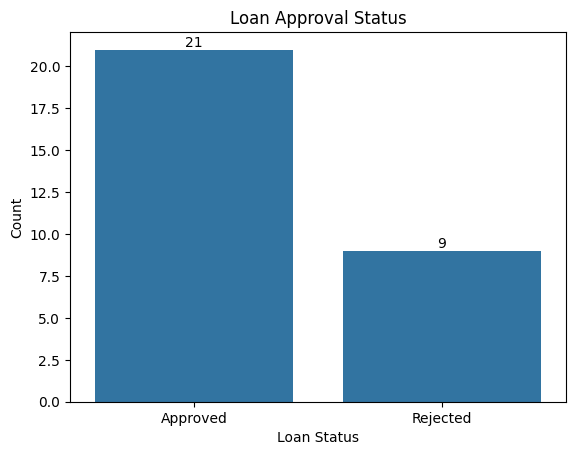

In [15]:
# Task 4: Data Visualization

# Create appropriate visualizations for:

# Loan Approval Status
ax = sns.countplot(data=df2, x='Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

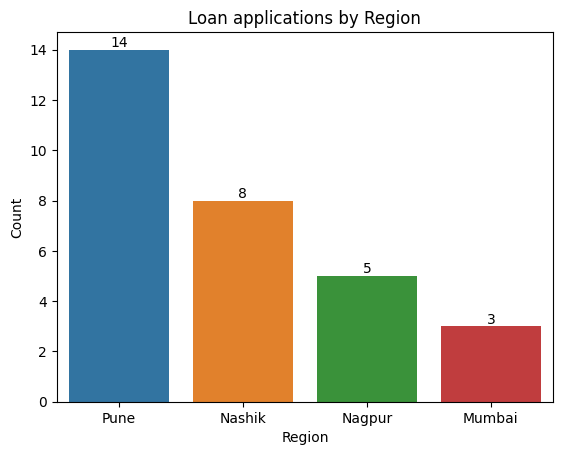

In [16]:
# Loan Applications by Region
ax = sns.countplot(df2, x='Region', hue='Region')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Loan applications by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

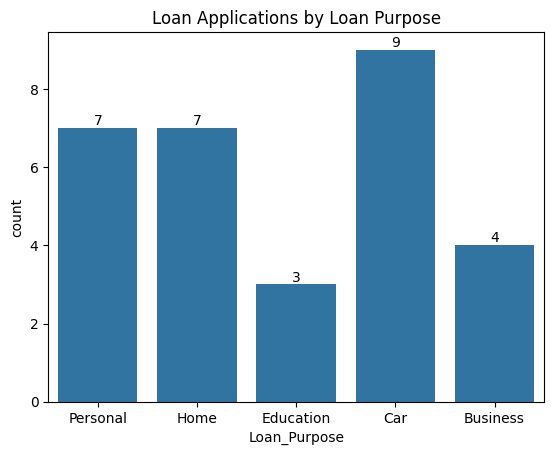

In [17]:
# Loan Applications by Loan Purpose
ax = sns.countplot(df2, x='Loan_Purpose')

for container in ax.containers:
    ax.bar_label(container)
plt.title('Loan Applications by Loan Purpose')
plt.show()


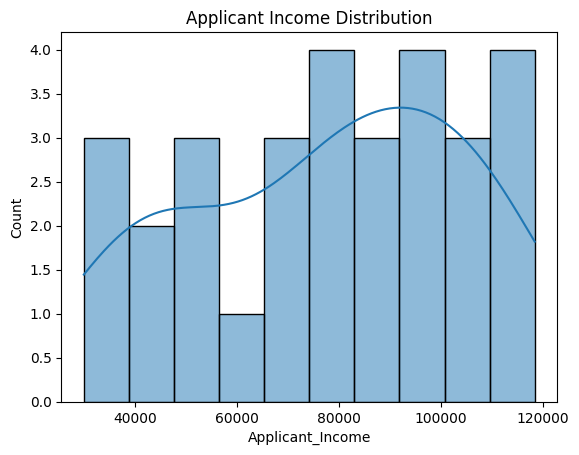

In [18]:
# Applicant Income Distribution
sns.histplot(df2, x='Applicant_Income', bins=10,kde=True)
plt.title("Applicant Income Distribution")
plt.show()

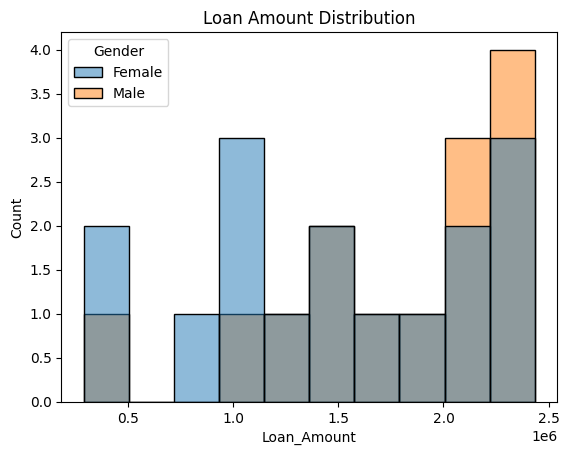

In [19]:
# Loan Amount Distribution
sns.histplot(df2, x='Loan_Amount', bins=10, hue='Gender')
plt.title('Loan Amount Distribution')
plt.show()

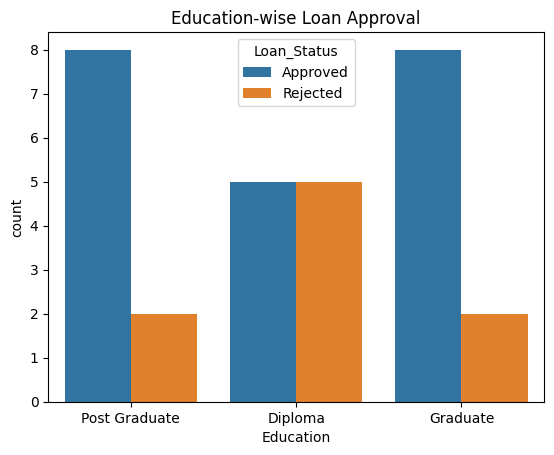

In [20]:
# Education-wise Loan Approval
sns.countplot(data=df2, x='Education', hue='Loan_Status')
plt.title('Education-wise Loan Approval')
plt.show()

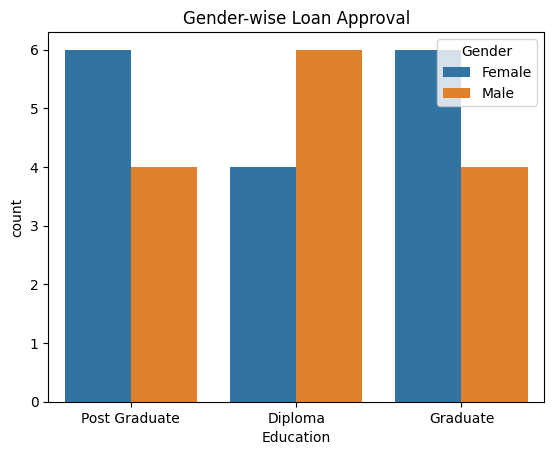

In [21]:
# Gender-wise Loan Approval
sns.countplot(data=df2, x='Education', hue='Gender')
plt.title('Gender-wise Loan Approval')
plt.show()

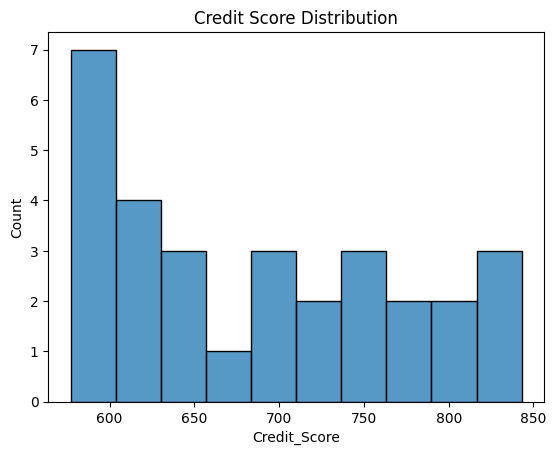

In [22]:
# Credit Score Distribution
sns.histplot(df2, x='Credit_Score',bins=10)
plt.title('Credit Score Distribution')
plt.show()

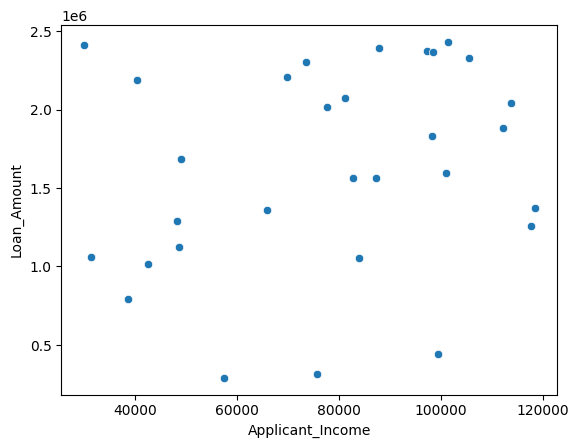

In [23]:
# Applicant Income vs Loan Amount (Scatter Plot)
sns.scatterplot(df2, x='Applicant_Income', y='Loan_Amount')
plt.show()

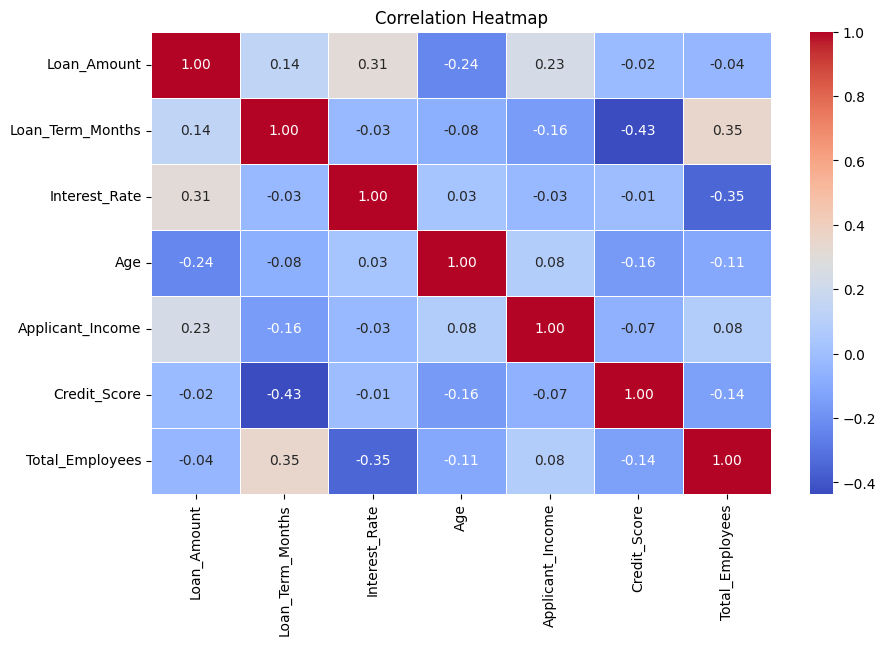

In [24]:
# Correlation Heatmap
corr = df2.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Task 5: Business Insights

# Based on your analysis, answer the following:

# Which region has the highest number of loan applications?
print(df2.groupby('Region')['Region'].value_counts().idxmax())

# Which loan purpose is most common?
print(df2.groupby('Loan_Purpose')['Loan_Purpose'].value_counts().idxmax())

# Which education category has the highest loan approval rate?
print(edu_rate.idxmax())

# Is there a relationship between applicant income and loan amount?
# Does a higher credit score improve the chances of loan approval?
# Which customer segment should the bank target for future loan offers?
# Provide 5 business recommendations based on your findings.

Pune
Car
Graduate
